# Chapter 02. 단어 빈도 분석과 Word Cloud 만들기

Chapter 01에서 만든 `book_bestseller_clean.csv`를 이용해
도서 제목에 어떤 단어가 자주 등장하는지 확인한다.

Word Cloud 이미지를 만드는 것만이 목적은 아니다.
같은 단어가 여러 번 등장할 때 **빈도를 어떻게 누적하는지** Dictionary로 직접 확인한 뒤,
`collections.Counter`와 pandas `value_counts()`로 같은 작업을 더 간단하게 처리해 본다.

그 다음 한글 형태소 분석으로 명사를 추출하고,
짧은 단어와 불용어를 제거한 뒤 상위 단어를 Word Cloud로 표현한다.

**진행 순서**

전처리 파일 불러오기 -> 상품명 확인 -> 단어 분리 원리 이해 -> Dictionary 빈도 누적
-> Counter 집계 -> value_counts() 비교 -> 형태소 분석 -> 명사 추출 -> 글자수 필터
-> 불용어 제거 -> 상위 30개 -> Word Cloud -> 원본 제목과 비교 검증 -> Markdown 정리

**최종 결과물**

- 상위 단어 빈도표
- `chapter02_top30_words.csv`
- `chapter02_wordcloud.png`
- 분석 결과 Markdown

> 인공지능이 만든 단어 목록이나 Word Cloud가 그럴듯해 보여도 바로 결과로 받아들이지 않는다.
> 실제 도서 제목에서 그 단어가 어떻게 쓰였는지 직접 확인한다.

---
# 실습 1. 전처리 데이터 불러오기

## 해야 할 일

Chapter 01에서 저장한 CSV를 pandas로 불러온다.
바로 단어를 분리하지 말고, 데이터가 제대로 연결되는지 먼저 확인한다.

## 프롬프트 예시

```
Python과 pandas를 처음 배우고 있습니다.
현재 Notebook과 같은 폴더에
book_bestseller_clean.csv 파일이 있습니다.
pandas로 이 파일을 df_books라는 DataFrame으로 불러오고,
다음 내용을 확인하는 가장 간단한 코드를 작성해 주세요.
1. 전체 행과 컬럼 개수
2. 컬럼 이름
3. 앞의 5행
4. '상품명' 컬럼이 존재하는지 확인
CSV는 utf-8-sig 인코딩을 사용했습니다.
초보자가 이해하기 쉽도록 불필요하게 복잡한 코드는 사용하지 말아 주세요.
try/except 예외 처리는 넣지 마세요.
초보자가 읽기 쉽게 10줄 이내로 짧게 작성해 주세요.
설명은 코드 옆 짧은 주석으로만 달아 주세요.
```

### 먼저 작업 폴더를 맞춘다

이 저장소의 `.vscode/settings.json`에 `"jupyter.notebookFileRoot": "${workspaceFolder}"`가 있어서,
Notebook을 실행하면 작업 폴더가 **저장소 루트**가 된다.
그래서 파일 이름만 적으면 `FileNotFoundError`가 난다.
아래 셀에서 작업 폴더를 `book-text-ml`로 맞춘 뒤 진행한다.

In [1]:
import os
from pathlib import Path

# 노트북이 있는 book-text-ml 폴더를 찾아 그쪽으로 이동한다.
# 폴더가 저장소 루트에 있든 notebooks 안에 있든 모두 찾는다.
if Path.cwd().name != "book-text-ml":
    for candidate in [Path("book-text-ml"), *Path(".").glob("*/book-text-ml")]:
        if candidate.is_dir():
            os.chdir(candidate)
            break

print("작업 폴더:", Path.cwd())

작업 폴더: C:\dev\llm-data-analysis-course\notebooks\book-text-ml


## 프롬프트 예시

```
Python과 pandas를 처음 배우고 있습니다.
현재 Notebook과 같은 폴더에 book_bestseller_clean.csv 파일이 있습니다.
pandas로 이 파일을 df_books라는 DataFrame으로 불러오고,
데이터 크기와 컬럼 이름, 앞의 5행을 확인하고 싶습니다.
CSV는 utf-8-sig 인코딩을 사용했습니다.
함수로 만들지 말고 바로 실행되는 코드로 작성해 주세요.
try/except 예외 처리는 넣지 마세요.
5줄 이내로 짧게 작성해 주세요.
설명은 코드 옆 짧은 주석으로만 달아 주세요.
```

In [2]:
import pandas as pd

DATA_PATH = "book_bestseller_clean.csv"
df_books = pd.read_csv(DATA_PATH, encoding="utf-8-sig")

print("데이터 크기:", df_books.shape)
print("컬럼:", df_books.columns.tolist())
df_books.head()

데이터 크기: (986, 8)
컬럼: ['순위', '판매상품ID', '상품명', '판매가', '저자', '출판사', '발행일', '분야']


,순위,판매상품ID,상품명,판매가,저자,출판사,발행일,분야
0,1,S000220308313,"세네카, 오늘을 빼앗기고 있는 당신에게",16200,세네카,논픽션,2026-07-01,인문
1,2,S000221248222,흔한남매 23,15120,흔한남매,미래엔아이세움,2026-09-16,어린이(초등)
2,3,S000221075112,머니 트렌드 2027,24750,정태익 외,북모먼트,2026-09-16,경제/경영
3,4,S000000620195,싯다르타,7200,헤르만 헤세,민음사,2002-01-20,소설
4,5,S000220693844,한국사 이상현상 연구원(일반판),19800,최인서,다이브,2026-08-31,소설


## 프롬프트 예시

```
DataFrame df_books에 '상품명'이라는 컬럼이 실제로 있는지
True/False로 확인하고 싶습니다.
함수로 만들지 말고 바로 실행되는 코드로 작성해 주세요.
try/except 예외 처리는 넣지 마세요.
5줄 이내로 짧게 작성해 주세요.
설명은 코드 옆 짧은 주석으로만 달아 주세요.
```

In [3]:
# 상품명 컬럼이 실제로 있는지 확인
print("상품명" in df_books.columns)

True


### 반드시 직접 확인할 것

- CSV 파일이 정상적으로 열렸는가
- 행 개수가 Chapter 01 결과와 크게 달라지지 않았는가
- 상품명 컬럼이 존재하는가
- 상품명이 한글로 정상적으로 보이는가

파일을 찾을 수 없다는 오류가 나면 코드보다 먼저 **현재 작업 폴더와 파일 위치**를 확인한다.

## 프롬프트 예시

```
Notebook에서 파일을 못 찾는 오류가 났습니다.
현재 작업 폴더와 데이터 파일이 실제로 존재하는지 확인하고 싶습니다.
함수로 만들지 말고 바로 실행되는 코드로 작성해 주세요.
try/except 예외 처리는 넣지 마세요.
5줄 이내로 짧게 작성해 주세요.
설명은 코드 옆 짧은 주석으로만 달아 주세요.
```

In [4]:
# 오류가 났을 때 확인용
from pathlib import Path
print(Path.cwd())
print(Path(DATA_PATH).exists())

C:\dev\llm-data-analysis-course\notebooks\book-text-ml
True


---
# 실습 2. 분석할 도서 제목 확인하기

## 해야 할 일

단어 분석을 시작하기 전에 상품명 데이터가 어떤 형태인지 직접 본다.

도서 제목에는 한글, 영어, 숫자, 괄호, 특수문자, 부제, 개정판 표시, 세트 표시가
함께 들어 있을 수 있다.
그래서 공백만 기준으로 나누면 원하는 단어가 제대로 분리되지 않는다.

다만 처음부터 형태소 분석으로 넘어가지 않는다.
먼저 간단한 문자열에서 빈도 집계 원리를 이해한 뒤 실제 데이터에 적용한다.

## 프롬프트 예시

```
DataFrame df_books의 상품명 컬럼이 어떻게 생겼는지
앞의 20개를 보고 싶습니다.
함수로 만들지 말고 바로 실행되는 코드로 작성해 주세요.
try/except 예외 처리는 넣지 마세요.
5줄 이내로 짧게 작성해 주세요.
설명은 코드 옆 짧은 주석으로만 달아 주세요.
```

In [5]:
# 상품명 일부 보기
df_books["상품명"].head(20)

0             세네카, 오늘을 빼앗기고 있는 당신에게
1                           흔한남매 23
2                       머니 트렌드 2027
3                              싯다르타
4                 한국사 이상현상 연구원(일반판)
5                                테오
6        쇼펜하우어 인생수업(30만 부 기념 개정증보판)
7                           니체의 초월자
8                            판매의 법칙
9                           마음의 어휘력
10                              수족관
11                   시대예보: 수고인류의 시간
12                         그랬다고 적었다
13               아름다운 것들은 비밀을 품고 있다
14                 똑똑한 사람은 어떻게 말하는가
15                               모순
16             돈의 흐름을 읽는 최소한의 경제 공부
17                             크래프터
18                       녹색 절벽의 신자들
19    기분이 태도가 되지 말자(30만부 기념 최신 개정판)
Name: 상품명, dtype: str

## 프롬프트 예시

```
DataFrame df_books의 상품명 컬럼에 결측치가 몇 개인지 확인하고 싶습니다.
함수로 만들지 말고 바로 실행되는 코드로 작성해 주세요.
try/except 예외 처리는 넣지 마세요.
5줄 이내로 짧게 작성해 주세요.
설명은 코드 옆 짧은 주석으로만 달아 주세요.
```

In [6]:
# 결측치 확인
print("상품명 결측치:", df_books["상품명"].isna().sum())

상품명 결측치: 0


## 프롬프트 예시

```
DataFrame df_books의 상품명 컬럼을 단어 분석에 쓸 수 있게 정리하고 싶습니다.
1. 결측치는 빈 문자열로 바꾸고
2. 모두 문자열로 통일하고
3. 앞뒤 공백을 제거하고
4. 내용이 없는 제목은 제외해서
titles라는 Series로 만들어 주세요.
마지막에 사용할 제목 개수와 앞부분을 확인해 주세요.
함수로 만들지 말고 바로 실행되는 코드로 작성해 주세요.
try/except 예외 처리는 넣지 마세요.
5줄 이내로 짧게 작성해 주세요.
설명은 코드 옆 짧은 주석으로만 달아 주세요.
```

In [7]:
# 문자열로 사용할 수 있도록 정리
titles = (
    df_books["상품명"]
    .fillna("")
    .astype(str)
    .str.strip()
)

# 비어 있는 제목은 제외
titles = titles[titles != ""]

print("사용할 제목 개수:", len(titles))
titles.head()

사용할 제목 개수: 986


0    세네카, 오늘을 빼앗기고 있는 당신에게
1                  흔한남매 23
2              머니 트렌드 2027
3                     싯다르타
4        한국사 이상현상 연구원(일반판)
Name: 상품명, dtype: str

---
# 실습 3. Dictionary로 단어 빈도 원리 이해하기

## 해야 할 일

빈도 분석의 핵심은 단순하다.

> 같은 단어가 등장할 때마다 그 단어의 숫자를 1씩 증가시킨다.

먼저 작은 예제로 원리를 확인한다.

## 프롬프트 예시

```
단어 빈도 분석의 원리를 이해하려고 합니다.
'데이터', '분석', '파이썬', '데이터', 'AI', '분석', '데이터'
이렇게 7개가 든 리스트를 sample_words라는 변수에 만들고 출력해 주세요.
함수로 만들지 말고 바로 실행되는 코드로 작성해 주세요.
try/except 예외 처리는 넣지 마세요.
5줄 이내로 짧게 작성해 주세요.
설명은 코드 옆 짧은 주석으로만 달아 주세요.
```

In [8]:
sample_words = [
    "데이터",
    "분석",
    "파이썬",
    "데이터",
    "AI",
    "분석",
    "데이터",
]

# 사람이 직접 세어 보면
# 데이터 3 / 분석 2 / 파이썬 1 / AI 1
print(sample_words)

['데이터', '분석', '파이썬', '데이터', 'AI', '분석', '데이터']


## 프롬프트 예시

```
단어가 든 리스트 sample_words가 있습니다.
Counter를 쓰지 말고, Python Dictionary와 for문만으로
각 단어가 몇 번 나왔는지 직접 세고 싶습니다.
이미 있는 단어면 1을 더하고 처음 나온 단어면 1로 시작하는 방식으로,
초보자가 원리를 알 수 있게 작성해 주세요.
함수로 만들지 말고 바로 실행되는 코드로 작성해 주세요.
try/except 예외 처리는 넣지 마세요.
5줄 이내로 짧게 작성해 주세요.
설명은 코드 옆 짧은 주석으로만 달아 주세요.
```

In [9]:
# Dictionary로 직접 누적하기
word_counts = {}

for word in sample_words:
    if word in word_counts:      # 이미 있는 단어면
        word_counts[word] += 1   # 1을 더하고
    else:                        # 처음 나온 단어면
        word_counts[word] = 1    # 1로 시작한다

print(word_counts)

{'데이터': 3, '분석': 2, '파이썬': 1, 'AI': 1}


## 프롬프트 예시

```
앞에서 if/else로 작성한 단어 세기 코드를
Dictionary의 get() 메서드를 이용해 더 짧게 바꾸고 싶습니다.
get(단어, 0)이 무슨 뜻인지 주석으로 짧게 설명해 주세요.
함수로 만들지 말고 바로 실행되는 코드로 작성해 주세요.
try/except 예외 처리는 넣지 마세요.
5줄 이내로 짧게 작성해 주세요.
설명은 코드 옆 짧은 주석으로만 달아 주세요.
```

In [10]:
# get()을 쓰면 더 짧게 쓸 수 있다
# get(word, 0) = 아직 없으면 0부터 시작하라는 뜻
word_counts = {}

for word in sample_words:
    word_counts[word] = word_counts.get(word, 0) + 1

print(word_counts)

{'데이터': 3, '분석': 2, '파이썬': 1, 'AI': 1}


### 기억할 것

문법을 외우는 것보다 아래 흐름을 이해하는 것이 중요하다.

> 단어 하나를 읽는다 -> 이전에 등장했는지 확인한다 -> 등장 횟수를 1 증가시킨다 -> 모든 단어에 반복한다

---
# 실습 4. Counter로 같은 작업 간단하게 처리하기

## 해야 할 일

Python에는 빈도 계산을 도와주는 `Counter`가 있다.
Dictionary로 직접 만든 결과와 같은 일을 한 줄로 처리한다.

## 프롬프트 예시

```
단어가 든 리스트 sample_words가 있습니다.
collections의 Counter를 이용해 단어 빈도를 세고 결과를 출력해 주세요.
함수로 만들지 말고 바로 실행되는 코드로 작성해 주세요.
try/except 예외 처리는 넣지 마세요.
5줄 이내로 짧게 작성해 주세요.
설명은 코드 옆 짧은 주석으로만 달아 주세요.
```

In [11]:
from collections import Counter

sample_counter = Counter(sample_words)
print(sample_counter)

Counter({'데이터': 3, '분석': 2, '파이썬': 1, 'AI': 1})


## 프롬프트 예시

```
Counter 객체 sample_counter가 있습니다.
가장 많이 등장한 단어부터 순서대로 보고 싶고,
상위 3개만 따로 보는 방법도 알고 싶습니다.
함수로 만들지 말고 바로 실행되는 코드로 작성해 주세요.
try/except 예외 처리는 넣지 마세요.
5줄 이내로 짧게 작성해 주세요.
설명은 코드 옆 짧은 주석으로만 달아 주세요.
```

In [12]:
# 가장 많이 등장한 단어부터 확인
print(sample_counter.most_common())
print()

# 상위 3개만
print(sample_counter.most_common(3))

[('데이터', 3), ('분석', 2), ('파이썬', 1), ('AI', 1)]

[('데이터', 3), ('분석', 2), ('파이썬', 1)]


### Dictionary와 Counter의 관계

두 방법은 다른 분석을 하는 것이 아니다.

| 방법 | 역할 |
|---|---|
| Dictionary | 빈도 누적 **원리를 직접 이해** |
| Counter | 같은 빈도 집계를 **더 간단하게 수행** |

이번 Chapter는 원리를 먼저 이해한 뒤 편리한 도구를 쓰는 순서로 진행한다.

---
# 실습 5. pandas value_counts()로 빈도 확인하기

## 해야 할 일

pandas에서도 같은 값이 몇 번 등장했는지 쉽게 확인할 수 있다.

## 프롬프트 예시

```
단어가 든 리스트 sample_words가 있습니다.
pandas Series로 바꾼 뒤 value_counts()로 빈도를 확인하고 싶습니다.
함수로 만들지 말고 바로 실행되는 코드로 작성해 주세요.
try/except 예외 처리는 넣지 마세요.
5줄 이내로 짧게 작성해 주세요.
설명은 코드 옆 짧은 주석으로만 달아 주세요.
```

In [13]:
sample_series = pd.Series(sample_words)
sample_series.value_counts()

데이터    3
분석     2
파이썬    1
AI     1
Name: count, dtype: int64

### 세 방법 비교

| 방법 | 특징 | 이번 실습에서의 의미 |
|---|---|---|
| Dictionary | 직접 빈도를 누적 | 원리 이해 |
| Counter | Python 표준 기능 | 간단한 빈도 집계 |
| `value_counts()` | pandas 기능 | Series 기반 분석 |

어느 하나만 정답인 것은 아니다. 상황에 따라 편한 방법을 선택한다.

---
# 실습 6. 실제 도서 제목을 간단하게 단어로 나누기

## 해야 할 일

이제 실제 상품명을 사용한다.
형태소 분석을 쓰기 전에 **정규표현식으로 단순 토큰화**를 먼저 해본다.

목적은 완벽한 단어 추출이 아니라,
실제 데이터에서도 빈도 집계 흐름이 어떻게 연결되는지 확인하는 것이다.

## 프롬프트 예시

```
한글 형태소 분석을 쓰기 전에 정규표현식으로 간단한 토큰화를 해보려고 합니다.
문장을 넣으면 한글, 영문, 숫자로 된 덩어리만 뽑아 리스트로 돌려주고
영문은 소문자로 통일하는 simple_tokenize(text) 함수를 만들고 싶습니다.
'AI 시대의 데이터 분석, Python으로 시작하기!'로 테스트도 해주세요.
try/except 예외 처리는 넣지 마세요.
초보자가 읽기 쉽게 10줄 이내로 짧게 작성해 주세요.
설명은 코드 옆 짧은 주석으로만 달아 주세요.
```

In [14]:
import re

def simple_tokenize(text):
    # 한글, 영문, 숫자로 이루어진 덩어리만 뽑고 소문자로 통일
    return re.findall(r"[가-힣A-Za-z0-9]+", str(text).lower())

sample_title = "AI 시대의 데이터 분석, Python으로 시작하기!"
print(simple_tokenize(sample_title))

['ai', '시대의', '데이터', '분석', 'python으로', '시작하기']


### 여기서 바로 한계가 보인다

```
'시대의'      <- '시대' + 조사 '의'
'python으로'  <- 'python' + 조사 '으로'
'시작하기'    <- '시작' + 어미
```

사람이 생각하는 의미 단위와 일치하지 않는다.
이것이 뒤에서 형태소 분석을 사용하는 이유다.

---
# 실습 7. 모든 제목에서 단어 추출하기

## 해야 할 일

단순 토큰화 방식으로 모든 제목의 단어를 하나의 리스트에 모은다.

## 프롬프트 예시

```
제목이 든 Series titles와 simple_tokenize(text) 함수가 있습니다.
모든 제목의 단어를 하나의 리스트 simple_words에 모으고 싶습니다.
전체 단어 수와 앞의 50개를 출력해 주세요.
함수로 만들지 말고 바로 실행되는 코드로 작성해 주세요.
try/except 예외 처리는 넣지 마세요.
5줄 이내로 짧게 작성해 주세요.
설명은 코드 옆 짧은 주석으로만 달아 주세요.
```

In [15]:
simple_words = []

for title in titles:
    words = simple_tokenize(title)
    simple_words.extend(words)

print("전체 단어 수:", len(simple_words))
print(simple_words[:50])

전체 단어 수: 4109
['세네카', '오늘을', '빼앗기고', '있는', '당신에게', '흔한남매', '23', '머니', '트렌드', '2027', '싯다르타', '한국사', '이상현상', '연구원', '일반판', '테오', '쇼펜하우어', '인생수업', '30만', '부', '기념', '개정증보판', '니체의', '초월자', '판매의', '법칙', '마음의', '어휘력', '수족관', '시대예보', '수고인류의', '시간', '그랬다고', '적었다', '아름다운', '것들은', '비밀을', '품고', '있다', '똑똑한', '사람은', '어떻게', '말하는가', '모순', '돈의', '흐름을', '읽는', '최소한의', '경제', '공부']


### append()가 아니라 extend()를 쓴 이유

## 프롬프트 예시

```
Python 리스트의 append()와 extend()가 어떻게 다른지
직접 눈으로 비교하고 싶습니다.
빈 리스트에 ['데이터', '분석']을 각각 append와 extend로 넣고
결과를 출력해 주세요.
함수로 만들지 말고 바로 실행되는 코드로 작성해 주세요.
try/except 예외 처리는 넣지 마세요.
5줄 이내로 짧게 작성해 주세요.
설명은 코드 옆 짧은 주석으로만 달아 주세요.
```

In [16]:
# append()는 리스트를 통째로 하나의 원소로 넣는다
example = []
example.append(["데이터", "분석"])
print("append :", example)

# extend()는 각 단어를 기존 리스트에 이어 붙인다
example = []
example.extend(["데이터", "분석"])
print("extend :", example)

append : [['데이터', '분석']]
extend : ['데이터', '분석']


빈도 분석에서는 단어가 하나씩 들어 있는 두 번째 형태가 쓰기 편하다.

---
# 실습 8. 실제 데이터에서 Counter로 빈도 확인하기

## 해야 할 일

단순 토큰화 결과의 빈도를 확인한다.
**여기서 바로 Word Cloud를 만들지 않는다.** 먼저 상위 단어를 눈으로 본다.

## 프롬프트 예시

```
단어가 든 리스트 simple_words가 있습니다.
Counter로 빈도를 세고 상위 30개를 확인하고 싶습니다.
함수로 만들지 말고 바로 실행되는 코드로 작성해 주세요.
try/except 예외 처리는 넣지 마세요.
5줄 이내로 짧게 작성해 주세요.
설명은 코드 옆 짧은 주석으로만 달아 주세요.
```

In [17]:
simple_counter = Counter(simple_words)
simple_counter.most_common(30)

[('2026', 60),
 ('2027', 56),
 ('1', 55),
 ('2', 30),
 ('에디션', 28),
 ('해커스', 25),
 ('기념', 19),
 ('세트', 18),
 ('기본서', 18),
 ('토익', 17),
 ('2026년', 17),
 ('한', 15),
 ('the', 15),
 ('읽는', 14),
 ('부', 13),
 ('기출문제집', 13),
 ('끝내는', 13),
 ('일본어', 13),
 ('초판본', 13),
 ('해커스경찰', 12),
 ('ncs', 12),
 ('4', 12),
 ('리커버', 11),
 ('ai', 11),
 ('jlpt', 11),
 ('모의고사', 11),
 ('공단기', 11),
 ('3', 11),
 ('위한', 11),
 ('기출', 10)]

## 프롬프트 예시

```
Counter 객체 simple_counter가 있습니다.
상위 30개를 '단어'와 '빈도' 두 컬럼을 가진
pandas DataFrame으로 만들어 표로 보고 싶습니다.
함수로 만들지 말고 바로 실행되는 코드로 작성해 주세요.
try/except 예외 처리는 넣지 마세요.
5줄 이내로 짧게 작성해 주세요.
설명은 코드 옆 짧은 주석으로만 달아 주세요.
```

In [18]:
simple_top30 = pd.DataFrame(
    simple_counter.most_common(30),
    columns=["단어", "빈도"]
)
simple_top30

,단어,빈도
0,2026,60
1,2027,56
2,1,55
3,2,30
4,에디션,28
5,해커스,25
6,기념,19
7,세트,18
8,기본서,18
9,토익,17


### 결과를 보고 다음 질문에 답해 본다

- 의미 없는 한 글자 단어가 많은가?
- 조사나 어미가 붙은 단어가 있는가?
- 같은 의미인데 다른 형태로 분리된 단어가 있는가?
- 숫자가 지나치게 많이 등장하는가?
- '개정판', '세트'처럼 분석 목적과 관계가 적은 표현이 많은가?

이 결과를 보고 **다음 전처리 방향을 결정한다.**

---
# 실습 9. pandas로도 실제 단어 빈도 확인하기

## 해야 할 일

같은 단어 리스트를 pandas Series로 바꿔 `value_counts()`로도 확인하고,
두 결과가 **같은지 검증**한다.

## 프롬프트 예시

```
단어가 든 리스트 simple_words가 있습니다.
pandas Series로 바꾼 뒤 value_counts()로 상위 30개를 확인하고 싶습니다.
함수로 만들지 말고 바로 실행되는 코드로 작성해 주세요.
try/except 예외 처리는 넣지 마세요.
5줄 이내로 짧게 작성해 주세요.
설명은 코드 옆 짧은 주석으로만 달아 주세요.
```

In [19]:
simple_word_series = pd.Series(simple_words)
simple_word_series.value_counts().head(30)

2026     60
2027     56
1        55
2        30
에디션      28
해커스      25
기념       19
세트       18
기본서      18
토익       17
2026년    17
한        15
the      15
읽는       14
부        13
기출문제집    13
끝내는      13
일본어      13
초판본      13
해커스경찰    12
ncs      12
4        12
리커버      11
ai       11
jlpt     11
모의고사     11
공단기      11
3        11
위한       11
기출       10
Name: count, dtype: int64

## 프롬프트 예시

```
같은 단어 리스트를 Counter와 pandas value_counts()로 각각 집계했습니다.
두 방법의 상위 10개가 정말 같은지 비교해서 확인하고 싶습니다.
두 결과를 출력하고 같은지 여부도 True/False로 보여 주세요.
함수로 만들지 말고 바로 실행되는 코드로 작성해 주세요.
try/except 예외 처리는 넣지 마세요.
5줄 이내로 짧게 작성해 주세요.
설명은 코드 옆 짧은 주석으로만 달아 주세요.
```

In [20]:
# 검증: 두 방법의 상위 10개가 같은지 확인
counter_top10 = simple_counter.most_common(10)
series_top10 = list(simple_word_series.value_counts().head(10).items())

print("Counter      :", counter_top10)
print("value_counts :", series_top10)
print()
print("두 결과가 같은가?:", counter_top10 == series_top10)

Counter      : [('2026', 60), ('2027', 56), ('1', 55), ('2', 30), ('에디션', 28), ('해커스', 25), ('기념', 19), ('세트', 18), ('기본서', 18), ('토익', 17)]
value_counts : [('2026', 60), ('2027', 56), ('1', 55), ('2', 30), ('에디션', 28), ('해커스', 25), ('기념', 19), ('세트', 18), ('기본서', 18), ('토익', 17)]

두 결과가 같은가?: True


두 결과가 다르다면 바로 다음 단계로 넘어가지 말고 **데이터 생성 과정부터** 다시 확인한다.

---
# 실습 10. 왜 형태소 분석이 필요한가?

한국어는 공백만으로 단어를 나누기 어렵다.

```
데이터를
데이터가
데이터의
데이터로
```

사람은 모두 핵심 단어가 **데이터**라고 이해하지만,
단순 공백 분리에서는 서로 다른 문자열로 처리된다.

또한 다음과 같은 조사가 단어처럼 섞인다.

```
은  는  이  가  을  를  의
```

빈도 분석에서 모든 품사가 항상 필요하지는 않다.
이번 실습에서는 도서 제목의 주요 주제를 보기 위해 **명사 중심**으로 단어를 추출한다.

---
# 실습 11. Kiwi 형태소 분석기 설치하기

## 해야 할 일

한글 형태소 분석 도구는 여러 가지가 있다.
이번 실습에서는 Windows에서도 설치가 비교적 간단한 `kiwipiepy`를 사용한다.

터미널에서 현재 사용하는 Python 가상환경이 활성화되어 있는지 확인한 뒤 설치한다.

```
python -m pip install kiwipiepy
```

설치 확인

```
python -m pip show kiwipiepy
```

Notebook에서 바로 설치했다면 **커널 재시작**이 필요한 경우도 있다.

## 프롬프트 예시

```
Windows와 VS Code Notebook 환경에서 Python을 배우고 있습니다.
한국어 도서 제목의 명사를 추출하기 위해
kiwipiepy를 설치하려고 합니다.
1. 현재 가상환경에 설치하는 명령
2. 설치 확인 명령
3. ModuleNotFoundError가 발생할 때 확인할 항목
을 초보자가 따라할 수 있게 순서대로 설명해 주세요.
함수로 만들지 말고 바로 실행되는 코드로 작성해 주세요.
try/except 예외 처리는 넣지 마세요.
5줄 이내로 짧게 작성해 주세요.
설명은 코드 옆 짧은 주석으로만 달아 주세요.
```

In [21]:
# 설치가 되었는지 Notebook에서 확인
import kiwipiepy
print("kiwipiepy 버전:", kiwipiepy.__version__)

kiwipiepy 버전: 0.23.2


---
# 실습 12. Kiwi로 한 문장 품사 확인하기

## 해야 할 일

전체 데이터에 적용하기 전에 **짧은 문장 하나**로 결과를 먼저 본다.

## 프롬프트 예시

```
kiwipiepy를 설치했습니다.
짧은 문장 하나를 형태소 분석해서 각 형태소와 품사 태그를 확인하고 싶습니다.
문장은 'AI 시대의 데이터 분석을 위한 파이썬'입니다.
함수로 만들지 말고 바로 실행되는 코드로 작성해 주세요.
try/except 예외 처리는 넣지 마세요.
5줄 이내로 짧게 작성해 주세요.
설명은 코드 옆 짧은 주석으로만 달아 주세요.
```

In [22]:
from kiwipiepy import Kiwi

kiwi = Kiwi()

sample_title = "AI 시대의 데이터 분석을 위한 파이썬"
tokens = kiwi.tokenize(sample_title)

for token in tokens:
    print(token.form, token.tag)

AI SL
시대 NNG
의 JKG
데이터 NNG
분석 NNG
을 JKO
위하 VV
ᆫ ETM
파이썬 NNP


### 이번 실습에서 사용할 품사 태그

| 태그 | 의미 |
|---|---|
| `NNG` | 일반 명사 |
| `NNP` | 고유 명사 |
| `SL` | 알파벳으로 된 외국어 |

`데이터`, `분석`, `파이썬` 같은 주요 명사와 `AI`, `Python` 같은 영문 표현을 분석 대상으로 쓴다.

### 중요한 점

형태소 분석 결과도 절대적인 정답은 아니다.
도서 제목에는 신조어, 제품명, 인물명, 영문 약어, 붙여 쓴 표현, 브랜드명이 많아
분석이 예상과 다를 수 있다. 따라서 **실제 결과를 반드시 확인한다.**

---
# 실습 13. 명사 중심으로 단어 추출하기

## 해야 할 일

사용할 품사를 정하고 단어 추출 함수를 만든다.

> 문장을 Kiwi로 분석 -> 형태소 하나씩 확인 -> NNG, NNP, SL만 선택
> -> 앞뒤 공백 제거 -> 영문은 소문자로 통일 -> 리스트로 반환

영문 대소문자를 통일하는 이유는 `AI`와 `ai`를 같은 단어로 집계하기 위해서다.

## 프롬프트 예시

```
Kiwi 객체 kiwi가 준비되어 있습니다.
문장을 넣으면 일반명사(NNG), 고유명사(NNP), 영문(SL)만 골라
리스트로 돌려주는 extract_words(text) 함수를 만들고 싶습니다.
앞뒤 공백을 제거하고 영문은 소문자로 통일해 주세요.
try/except 예외 처리는 넣지 마세요.
초보자가 읽기 쉽게 10줄 이내로 짧게 작성해 주세요.
설명은 코드 옆 짧은 주석으로만 달아 주세요.
```

In [23]:
TARGET_TAGS = {"NNG", "NNP", "SL"}

def extract_words(text):
    result = []
    for token in kiwi.tokenize(str(text)):
        if token.tag in TARGET_TAGS:
            word = token.form.strip().lower()
            result.append(word)
    return result

# 테스트
print(extract_words("AI 시대의 데이터 분석을 위한 파이썬"))

['ai', '시대', '데이터', '분석', '파이썬']


---
# 실습 14. 최소 글자수 필터링 적용하기

## 해야 할 일

한 글자 단어가 모두 의미 없는 것은 아니다.
하지만 도서 제목 빈도 분석에서 한 글자 토큰이 너무 많으면 결과를 해석하기 어렵다.

이번 실습에서는 **2글자 이상**을 사용한다. 영문 `ai`는 2글자이므로 포함된다.

### 주의

2글자 이상은 자연 법칙이 아니라 **이번 분석을 위한 규칙**이다.
한 글자 단어가 중요한 분야라면 기준을 바꿔야 한다.
그래서 보고서에는 조건을 명시하는 것이 좋다.

> 이번 분석에서는 노이즈를 줄이기 위해 2글자 이상의 명사와 영문 토큰을 사용했다.

## 프롬프트 예시

```
앞에서 만든 extract_words(text) 함수에 조건을 하나 더 넣고 싶습니다.
2글자 이상인 단어만 남기도록 수정해 주세요.
기준 값은 MIN_LENGTH라는 변수로 빼주세요.
try/except 예외 처리는 넣지 마세요.
초보자가 읽기 쉽게 10줄 이내로 짧게 작성해 주세요.
설명은 코드 옆 짧은 주석으로만 달아 주세요.
```

In [24]:
MIN_LENGTH = 2

def extract_words(text):
    result = []
    for token in kiwi.tokenize(str(text)):
        if token.tag in TARGET_TAGS:
            word = token.form.strip().lower()
            if len(word) >= MIN_LENGTH:
                result.append(word)
    return result

print(extract_words("AI 시대의 데이터 분석을 위한 파이썬"))

['ai', '시대', '데이터', '분석', '파이썬']


---
# 실습 15. 모든 도서 제목에서 명사 추출하기

## 해야 할 일

전체 제목에 함수를 적용하고, 단순 토큰화 결과와 비교한다.

## 프롬프트 예시

```
제목이 든 Series titles와 extract_words(text) 함수가 있습니다.
모든 제목에서 추출한 단어를 filtered_words 리스트에 모으고 싶습니다.
전체 단어 수와 앞의 50개를 출력해 주세요.
함수로 만들지 말고 바로 실행되는 코드로 작성해 주세요.
try/except 예외 처리는 넣지 마세요.
5줄 이내로 짧게 작성해 주세요.
설명은 코드 옆 짧은 주석으로만 달아 주세요.
```

In [25]:
filtered_words = []
for title in titles:
    filtered_words.extend(extract_words(title))

print("추출된 전체 단어 수:", len(filtered_words))
print(filtered_words[:50])

추출된 전체 단어 수: 2927
['세네카', '오늘', '남매', '머니', '트렌드', '싯다르타', '한국사', '이상', '현상', '연구원', '일반판', '테오', '쇼펜하우어', '인생', '수업', '기념', '개정', '증보판', '니체', '초월자', '판매', '법칙', '마음', '어휘력', '수족관', '시대', '예보', '인류', '시간', '비밀', '사람', '모순', '흐름', '최소한', '경제', '공부', '크래프터', '녹색', '절벽', '신자', '기분', '태도', '기념', '최신', '개정판', '브람스', '부동산', '교과서', '서리', '세트']


## 프롬프트 예시

```
단어가 든 리스트 filtered_words가 있습니다.
Counter로 빈도를 세고 상위 30개를
'단어'와 '빈도' 컬럼을 가진 DataFrame으로 만들어 주세요.
함수로 만들지 말고 바로 실행되는 코드로 작성해 주세요.
try/except 예외 처리는 넣지 마세요.
5줄 이내로 짧게 작성해 주세요.
설명은 코드 옆 짧은 주석으로만 달아 주세요.
```

In [26]:
noun_counter = Counter(filtered_words)
noun_top30 = pd.DataFrame(
    noun_counter.most_common(30),
    columns=["단어", "빈도"]
)
noun_top30

,단어,빈도
0,해커스,51
1,기출,40
2,에디션,30
3,기념,28
4,모의고사,24
5,기본,23
6,일본어,22
7,경찰,20
8,사랑,20
9,세트,19


## 프롬프트 예시

```
단순 토큰화 결과 DataFrame(simple_top30)과
형태소 분석 결과 DataFrame(noun_top30)이 있습니다.
두 표의 상위 10개를 나란히 출력해 비교하고 싶습니다.
Jupyter에서 표 형태가 유지되도록 display()를 사용해 주세요.
함수로 만들지 말고 바로 실행되는 코드로 작성해 주세요.
try/except 예외 처리는 넣지 마세요.
5줄 이내로 짧게 작성해 주세요.
설명은 코드 옆 짧은 주석으로만 달아 주세요.
```

In [27]:
# 단순 토큰화 결과와 비교
print("단순 토큰화 상위 10개")
display(simple_top30.head(10))

print("형태소 분석 후 상위 10개")
display(noun_top30.head(10))

단순 토큰화 상위 10개


,단어,빈도
0,2026,60
1,2027,56
2,1,55
3,2,30
4,에디션,28
5,해커스,25
6,기념,19
7,세트,18
8,기본서,18
9,토익,17


형태소 분석 후 상위 10개


,단어,빈도
0,해커스,51
1,기출,40
2,에디션,30
3,기념,28
4,모의고사,24
5,기본,23
6,일본어,22
7,경찰,20
8,사랑,20
9,세트,19


### 다음 질문에 답해 본다

- 형태소 분석 후 조사나 불필요한 표현이 줄었는가?
- 의미 있는 주제어가 더 잘 보이는가?
- 오히려 중요한 단어가 사라진 것은 없는가?

---
# 실습 16. 불용어 이해하기

형태소 분석 후에도 분석 목적과 관계가 적은 단어가 상위에 나타날 수 있다.
예를 들어 `세트`, `개정판`, `에디션`, `리커버`, `한정판` 같은 표현이다.

이런 단어를 **불용어(stopwords)** 로 지정해 제외할 수 있다.

하지만 불용어는 많이 제거한다고 좋은 것이 아니다.
특히 **결과를 보기도 전에** 임의로 많은 단어를 제거하면
분석자가 원하는 결과만 남기는 문제가 생긴다.

### 권장 순서

1. 먼저 빈도 결과 확인
2. 원본 제목에서 단어가 어떻게 사용됐는지 확인
3. 분석 목적과 관계가 적은지 판단
4. 불용어에 추가
5. 결과 다시 확인

---
# 실습 17. 불용어 목록 만들기

## 해야 할 일

처음에는 너무 많은 단어를 넣지 않는다.
실제 데이터에서 그 표현이 의미가 있다면 제거하지 않아도 된다.

완성된 함수에는 세 가지 필터가 들어간다.

| 필터 | 기준 |
|---|---|
| 품사 필터 | NNG, NNP, SL |
| 길이 필터 | 2글자 이상 |
| 불용어 필터 | STOPWORDS에 없는 단어 |

## 프롬프트 예시

```
앞에서 만든 extract_words(text) 함수에 조건을 하나 더 넣고 싶습니다.
2글자 이상인 단어만 남기도록 수정해 주세요.
기준 값은 MIN_LENGTH라는 변수로 빼주세요.
try/except 예외 처리는 넣지 마세요.
초보자가 읽기 쉽게 10줄 이내로 짧게 작성해 주세요.
설명은 코드 옆 짧은 주석으로만 달아 주세요.
```

In [28]:
TARGET_TAGS = {"NNG", "NNP", "SL"}
MIN_LENGTH = 2
STOPWORDS = {
    "세트",
    "개정판",
    "에디션",
    "리커버",
    "한정판",
}

def extract_words(text):
    result = []
    for token in kiwi.tokenize(str(text)):
        if token.tag not in TARGET_TAGS:
            continue
        word = token.form.strip().lower()
        if len(word) < MIN_LENGTH:
            continue
        if word in STOPWORDS:
            continue
        result.append(word)
    return result

print(extract_words("AI 시대의 데이터 분석 개정판 세트"))

['ai', '시대', '데이터', '분석']


---
# 실습 18. 최종 단어 목록 만들기

## 해야 할 일

세 필터를 모두 적용해 최종 단어 목록과 상위 30개 표를 만들고 파일로 저장한다.

## 프롬프트 예시

```
제목이 든 Series titles와 불용어까지 적용된 extract_words(text) 함수가 있습니다.
모든 제목에서 단어를 뽑아 final_words 리스트에 모으고 싶습니다.
최종 단어 수와 앞의 50개를 출력해 주세요.
함수로 만들지 말고 바로 실행되는 코드로 작성해 주세요.
try/except 예외 처리는 넣지 마세요.
5줄 이내로 짧게 작성해 주세요.
설명은 코드 옆 짧은 주석으로만 달아 주세요.
```

In [29]:
final_words = []
for title in titles:
    final_words.extend(extract_words(title))

print("최종 단어 수:", len(final_words))
print(final_words[:50])

최종 단어 수: 2856
['세네카', '오늘', '남매', '머니', '트렌드', '싯다르타', '한국사', '이상', '현상', '연구원', '일반판', '테오', '쇼펜하우어', '인생', '수업', '기념', '개정', '증보판', '니체', '초월자', '판매', '법칙', '마음', '어휘력', '수족관', '시대', '예보', '인류', '시간', '비밀', '사람', '모순', '흐름', '최소한', '경제', '공부', '크래프터', '녹색', '절벽', '신자', '기분', '태도', '기념', '최신', '브람스', '부동산', '교과서', '서리', '군주론', '쇼츠']


## 프롬프트 예시

```
단어가 든 리스트 final_words가 있습니다.
Counter로 빈도를 세고 상위 30개를
'단어'와 '빈도' 컬럼을 가진 DataFrame top30으로 만들어 주세요.
함수로 만들지 말고 바로 실행되는 코드로 작성해 주세요.
try/except 예외 처리는 넣지 마세요.
5줄 이내로 짧게 작성해 주세요.
설명은 코드 옆 짧은 주석으로만 달아 주세요.
```

In [30]:
final_counter = Counter(final_words)
top30 = pd.DataFrame(
    final_counter.most_common(30),
    columns=["단어", "빈도"]
)
top30

,단어,빈도
0,해커스,51
1,기출,40
2,기념,28
3,모의고사,24
4,기본,23
5,일본어,22
6,경찰,20
7,사랑,20
8,토익,19
9,사람,17


## 프롬프트 예시

```
상위 30개 단어가 든 DataFrame top30이 있습니다.
chapter02_top30_words.csv로 저장하고 싶습니다.
utf-8-sig 인코딩을 쓰고 인덱스는 저장하지 말아 주세요.
파일이 실제로 만들어졌는지 확인하는 코드도 넣어 주세요.
함수로 만들지 말고 바로 실행되는 코드로 작성해 주세요.
try/except 예외 처리는 넣지 마세요.
5줄 이내로 짧게 작성해 주세요.
설명은 코드 옆 짧은 주석으로만 달아 주세요.
```

In [31]:
top30.to_csv(
    "chapter02_top30_words.csv",
    index=False,
    encoding="utf-8-sig"
)

from pathlib import Path
print("파일 생성 확인:", Path("chapter02_top30_words.csv").exists())

파일 생성 확인: True


---
# 실습 19. 상위 단어를 막대그래프로 먼저 확인하기

## 해야 할 일

Word Cloud는 직관적이지만 **정확한 빈도 비교에는 막대그래프가 더 편하다.**
Word Cloud를 만들기 전에 상위 단어를 막대그래프로 확인한다.

Windows에서 한글이 깨지면 Matplotlib 한글 폰트를 먼저 설정해야 한다.

## 프롬프트 예시

```
Windows에서 matplotlib 그래프의 한글이 깨집니다.
맑은 고딕으로 폰트를 설정하고 마이너스 기호도 깨지지 않게 하고 싶습니다.
함수로 만들지 말고 바로 실행되는 코드로 작성해 주세요.
try/except 예외 처리는 넣지 마세요.
5줄 이내로 짧게 작성해 주세요.
설명은 코드 옆 짧은 주석으로만 달아 주세요.
```

In [32]:
import matplotlib.pyplot as plt

# Windows 한글 폰트 설정 (깨짐 방지)
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

print("폰트 설정 완료:", plt.rcParams["font.family"])

폰트 설정 완료: ['Malgun Gothic']


## 프롬프트 예시

```
상위 30개 단어가 든 DataFrame top30이 있습니다.
빈도를 가로 막대그래프로 그리고 싶습니다.
빈도가 작은 것부터 아래에서 위로 쌓이게 정렬하고,
x축·y축 이름과 제목을 한글로 넣어 주세요.
함수로 만들지 말고 바로 실행되는 코드로 작성해 주세요.
try/except 예외 처리는 넣지 마세요.
5줄 이내로 짧게 작성해 주세요.
설명은 코드 옆 짧은 주석으로만 달아 주세요.
```

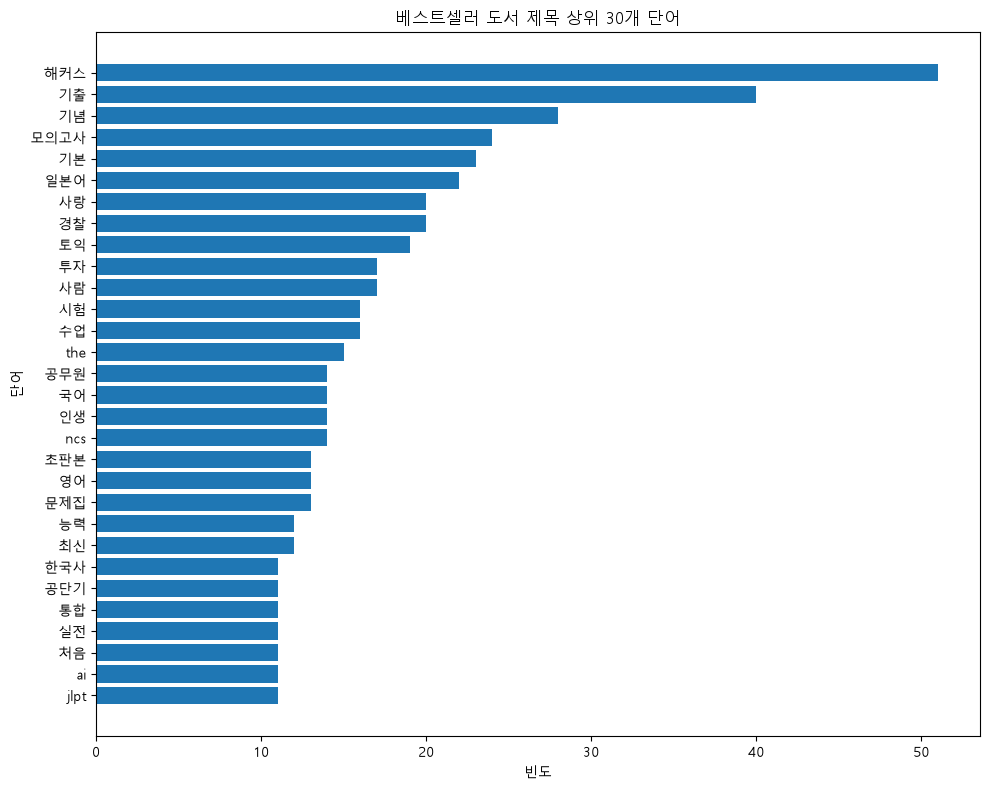

In [33]:
plot_data = top30.sort_values("빈도", ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(plot_data["단어"], plot_data["빈도"])
plt.xlabel("빈도")
plt.ylabel("단어")
plt.title("베스트셀러 도서 제목 상위 30개 단어")
plt.tight_layout()
plt.show()

### 확인할 것

- 한글이 깨지지 않는가?
- 가장 빈도가 높은 단어가 표의 결과와 같은가?
- 막대 길이와 빈도 숫자가 자연스럽게 대응하는가?

---
# 실습 20. Word Cloud 설치하기

Word Cloud 라이브러리가 없다면 현재 가상환경에 설치한다.

```
python -m pip install wordcloud matplotlib
```

설치 확인

```
python -m pip show wordcloud
```

## 프롬프트 예시

```
Word Cloud를 만들기 위해 wordcloud를 설치했습니다.
Notebook에서 import가 되는지 확인하고 싶습니다.
함수로 만들지 말고 바로 실행되는 코드로 작성해 주세요.
try/except 예외 처리는 넣지 마세요.
5줄 이내로 짧게 작성해 주세요.
설명은 코드 옆 짧은 주석으로만 달아 주세요.
```

In [34]:
from wordcloud import WordCloud
print("wordcloud 사용 가능")

wordcloud 사용 가능


---
# 실습 21. Word Cloud용 한글 폰트 확인하기

## 해야 할 일

Word Cloud에서 한글을 정상 표시하려면 **한글 폰트 파일 경로**가 필요하다.
Windows의 맑은 고딕 경로는 보통 다음과 같다.

```
C:/Windows/Fonts/malgun.ttf
```

### 중요한 점

폰트 경로는 운영체제와 PC 환경에 따라 다르다.
가이드의 경로가 본인 환경과 반드시 같아야 하는 것은 아니다.
`False`가 나오면 본인 PC에 설치된 다른 한글 폰트 경로를 확인한다.

## 프롬프트 예시

```
Word Cloud에서 한글을 표시하려면 한글 폰트 파일 경로가 필요합니다.
Windows 맑은 고딕 경로를 FONT_PATH 변수에 담고
그 파일이 실제로 존재하는지 확인하고 싶습니다.
함수로 만들지 말고 바로 실행되는 코드로 작성해 주세요.
try/except 예외 처리는 넣지 마세요.
5줄 이내로 짧게 작성해 주세요.
설명은 코드 옆 짧은 주석으로만 달아 주세요.
```

In [35]:
from pathlib import Path

FONT_PATH = Path("C:/Windows/Fonts/malgun.ttf")
print("폰트 경로:", FONT_PATH)
print("파일 존재 여부:", FONT_PATH.exists())

폰트 경로: C:\Windows\Fonts\malgun.ttf
파일 존재 여부: True


---
# 실습 22. Word Cloud 생성하기

## 해야 할 일

Word Cloud는 **단어 빈도 Dictionary를 바로 사용**할 수 있다.
`Counter`도 Dictionary와 유사한 형태라 그대로 넣을 수 있다.

## 프롬프트 예시

```
단어 빈도가 든 Counter 객체 final_counter와
한글 폰트 경로 FONT_PATH가 있습니다.
가로 1200, 세로 700, 흰 배경, 최대 100단어로 Word Cloud를 만들고 싶습니다.
실행할 때마다 결과가 같도록 random_state도 지정해 주세요.
함수로 만들지 말고 바로 실행되는 코드로 작성해 주세요.
try/except 예외 처리는 넣지 마세요.
5줄 이내로 짧게 작성해 주세요.
설명은 코드 옆 짧은 주석으로만 달아 주세요.
```

In [36]:
wordcloud = WordCloud(
    font_path=str(FONT_PATH),
    width=1200,
    height=700,
    background_color="white",
    max_words=100,
    random_state=42,
).generate_from_frequencies(final_counter)

print("Word Cloud 생성 완료")

Word Cloud 생성 완료


## 프롬프트 예시

```
만들어진 wordcloud 객체를 화면에 띄우고 싶습니다.
축은 보이지 않게 하고 한글 제목을 넣어 주세요.
함수로 만들지 말고 바로 실행되는 코드로 작성해 주세요.
try/except 예외 처리는 넣지 마세요.
5줄 이내로 짧게 작성해 주세요.
설명은 코드 옆 짧은 주석으로만 달아 주세요.
```

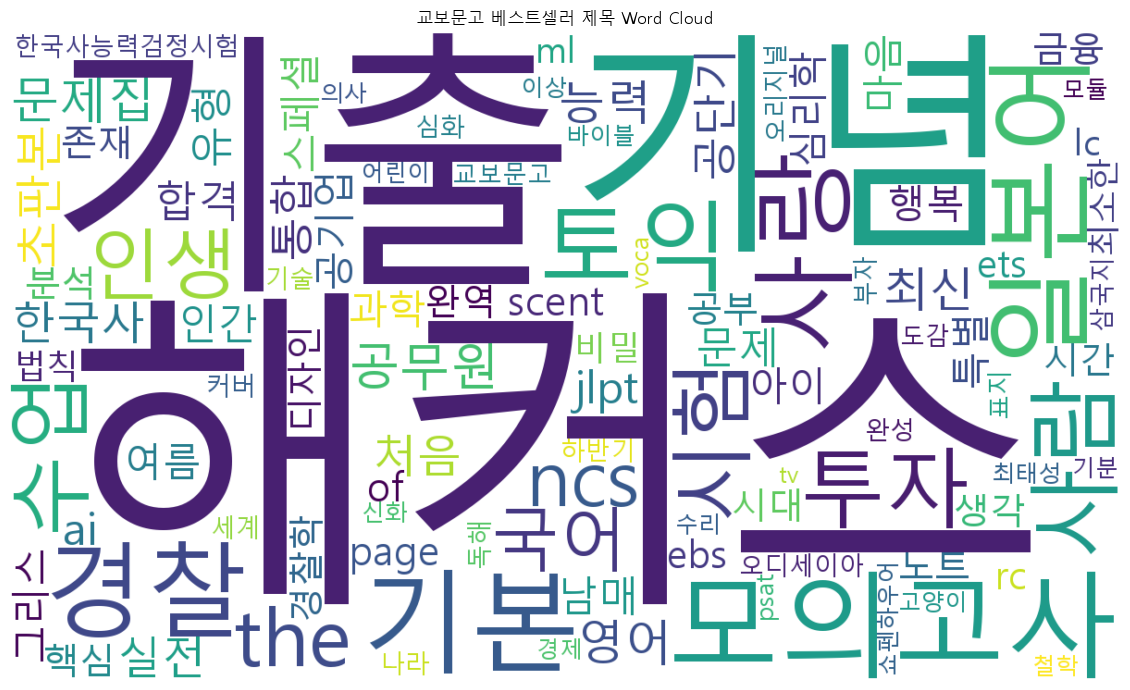

In [37]:
plt.figure(figsize=(12, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("교보문고 베스트셀러 제목 Word Cloud")
plt.tight_layout()
plt.show()

## 프롬프트 예시

```
만들어진 wordcloud를 chapter02_wordcloud.png 이미지 파일로 저장하고,
파일이 실제로 만들어졌는지 확인하고 싶습니다.
함수로 만들지 말고 바로 실행되는 코드로 작성해 주세요.
try/except 예외 처리는 넣지 마세요.
5줄 이내로 짧게 작성해 주세요.
설명은 코드 옆 짧은 주석으로만 달아 주세요.
```

In [38]:
wordcloud.to_file("chapter02_wordcloud.png")
print("이미지 저장 확인:", Path("chapter02_wordcloud.png").exists())

이미지 저장 확인: True


---
# 실습 23. Word Cloud를 어떻게 해석해야 할까?

Word Cloud에서 글자가 크게 보인다는 것은
**이번 분석 조건에서 더 많이 등장했다**는 의미다.

### 이렇게 해석한다

> 분석에 사용한 베스트셀러 도서 제목에서 '데이터'라는 단어가 상대적으로 자주 등장했다.

### 이렇게 해석하면 안 된다

> 데이터라는 주제가 베스트셀러 판매의 원인이다.
> 독자들이 데이터 책을 가장 좋아한다.

이번 데이터는 **도서 제목의 단어 빈도**를 보고 있을 뿐이다.

> **자주 등장한 단어와 중요한 원인은 같은 개념이 아니다.**

---
# 실습 24. 상위 단어를 원본 제목에서 다시 확인하기

## 해야 할 일

빈도 결과가 맞는지 확인하는 가장 좋은 방법은 **원본 데이터로 돌아가는 것**이다.

형태소 분석에서 같은 단어로 집계되어도 실제 제목에서는 다른 문맥으로 쓰였을 수 있다.
또 단순 문자열 검색과 형태소 분석 결과의 빈도는 정확히 일치하지 않을 수도 있다.
(형태가 변형되었거나 합성어의 일부로 분석되었을 수 있다.)

## 프롬프트 예시

```
상위 단어가 든 DataFrame top30이 있습니다.
빈도 1위 단어가 무엇인지 확인하고 싶습니다.
함수로 만들지 말고 바로 실행되는 코드로 작성해 주세요.
try/except 예외 처리는 넣지 마세요.
5줄 이내로 짧게 작성해 주세요.
설명은 코드 옆 짧은 주석으로만 달아 주세요.
```

In [39]:
target_word = top30.iloc[0]["단어"]
print("확인할 단어:", target_word)

확인할 단어: 해커스


## 프롬프트 예시

```
DataFrame df_books와 확인할 단어 target_word가 있습니다.
상품명에 그 단어가 들어 있는 도서를 찾아
상품명과 분야 두 컬럼만 보고 싶습니다.
대소문자는 구분하지 말고, 정규표현식으로 해석하지 말아 주세요.
검색된 도서 수와 앞의 20개를 보여 주세요.
함수로 만들지 말고 바로 실행되는 코드로 작성해 주세요.
try/except 예외 처리는 넣지 마세요.
5줄 이내로 짧게 작성해 주세요.
설명은 코드 옆 짧은 주석으로만 달아 주세요.
```

In [40]:
matched_titles = df_books[
    df_books["상품명"].astype(str).str.contains(
        str(target_word),
        case=False,
        na=False,
        regex=False,
    )
][["상품명", "분야"]]

print("문자열로 검색된 도서 수:", len(matched_titles))
matched_titles.head(20)

문자열로 검색된 도서 수: 51


,상품명,분야
41,2027 해커스경찰 갓대환 형사법 기출총정리 세트,취업/수험서
87,해커스 토익 기출 VOCA(보카),외국어
102,2026 해커스 GSAT 삼성직무적성검사 통합 기본서 최신기출유형+실전모의고사 (수...,취업/수험서
107,2027 해커스경찰 김민철 경찰학 기출 1000제,취업/수험서
111,2026 단기 합격 해커스공기업 NCS 통합 기본서(모듈형+피듈형+PSAT형+모의고...,취업/수험서
120,2026 해커스경찰 갓대환 형사법 기본서 2: 형사소송법 수사와 증거,취업/수험서
138,2026 해커스 GSAT 삼성직무적성검사 통합 기본서 최신기출유형+실전모의고사 (수...,미분류
144,한 권으로 끝내는 해커스 토익 800+(LC+RC+VOCA),외국어
178,2027 해커스공무원 영어 구조 독해 007,취업/수험서
182,2026 해커스경찰 갓대환 형사법 기본서 1: 형법,취업/수험서


## 프롬프트 예시

```
형태소 분석으로 센 단어 빈도(final_counter)와
단순 문자열 검색으로 찾은 도서 수(matched_titles)가 있습니다.
두 숫자를 나란히 출력해 비교하고 싶습니다.
세는 기준이 달라 숫자가 다를 수 있다는 점도 함께 출력해 주세요.
함수로 만들지 말고 바로 실행되는 코드로 작성해 주세요.
try/except 예외 처리는 넣지 마세요.
5줄 이내로 짧게 작성해 주세요.
설명은 코드 옆 짧은 주석으로만 달아 주세요.
```

In [41]:
# 형태소 분석 기준 빈도와 단순 문자열 검색 결과 비교
print("형태소 분석 빈도:", final_counter[target_word])
print("문자열 포함 도서 수:", len(matched_titles))
print()
print("두 숫자는 다를 수 있다. 세는 기준이 다르기 때문이다.")

형태소 분석 빈도: 51
문자열 포함 도서 수: 51

두 숫자는 다를 수 있다. 세는 기준이 다르기 때문이다.


---
# 실습 25. 상위 10개 단어의 빈도 합 검증하기

## 해야 할 일

분석 결과가 만들어졌다고 바로 끝내지 않는다. 일부 숫자를 직접 확인한다.

## 프롬프트 예시

```
Counter 객체 final_counter와 DataFrame top30이 있습니다.
두 결과의 상위 10개가 정말 같은지 비교해서 확인하고 싶습니다.
두 결과를 출력하고 같은지 여부도 True/False로 보여 주세요.
함수로 만들지 말고 바로 실행되는 코드로 작성해 주세요.
try/except 예외 처리는 넣지 마세요.
5줄 이내로 짧게 작성해 주세요.
설명은 코드 옆 짧은 주석으로만 달아 주세요.
```

In [42]:
top10 = final_counter.most_common(10)

print("Counter 상위 10개:")
print(top10)
print()
print("DataFrame 상위 10개:")
print(top30.head(10).values.tolist())
print()
print("두 결과가 같은가?:", [list(x) for x in top10] == top30.head(10).values.tolist())

Counter 상위 10개:
[('해커스', 51), ('기출', 40), ('기념', 28), ('모의고사', 24), ('기본', 23), ('일본어', 22), ('경찰', 20), ('사랑', 20), ('토익', 19), ('사람', 17)]

DataFrame 상위 10개:
[['해커스', 51], ['기출', 40], ['기념', 28], ['모의고사', 24], ['기본', 23], ['일본어', 22], ['경찰', 20], ['사랑', 20], ['토익', 19], ['사람', 17]]

두 결과가 같은가?: True


## 프롬프트 예시

```
Counter 객체 final_counter와 원본 리스트 final_words가 있습니다.
Counter의 전체 빈도 합과 리스트 길이가 같은지 확인하고 싶습니다.
두 값을 출력하고 같은지 여부도 보여 주세요.
함수로 만들지 말고 바로 실행되는 코드로 작성해 주세요.
try/except 예외 처리는 넣지 마세요.
5줄 이내로 짧게 작성해 주세요.
설명은 코드 옆 짧은 주석으로만 달아 주세요.
```

In [43]:
print("Counter 전체 빈도 합:", sum(final_counter.values()))
print("final_words 길이   :", len(final_words))
print()
print("두 숫자는 같아야 한다 ->", sum(final_counter.values()) == len(final_words))

Counter 전체 빈도 합: 2856
final_words 길이   : 2856

두 숫자는 같아야 한다 -> True


이런 간단한 검증을 넣으면
**코드가 실행되었다는 사실**과 **분석이 논리적으로 맞는지**를 구분할 수 있다.

---
# 실습 26. 불용어 적용 전후 비교하기

## 해야 할 일

불용어를 추가했다면 결과가 어떻게 바뀌었는지 비교한다.

- 적용 전: `noun_counter`
- 적용 후: `final_counter`

## 프롬프트 예시

```
불용어 적용 전 Counter(noun_counter)와
적용 후 Counter(final_counter)가 있습니다.
각각 상위 20개를 뽑아 한 표에 나란히 놓고 비교하고 싶습니다.
컬럼 이름에 '적용 전', '적용 후'를 넣어 주세요.
함수로 만들지 말고 바로 실행되는 코드로 작성해 주세요.
try/except 예외 처리는 넣지 마세요.
5줄 이내로 짧게 작성해 주세요.
설명은 코드 옆 짧은 주석으로만 달아 주세요.
```

In [44]:
before_top20 = pd.DataFrame(
    noun_counter.most_common(20),
    columns=["적용 전 단어", "적용 전 빈도"]
)
after_top20 = pd.DataFrame(
    final_counter.most_common(20),
    columns=["적용 후 단어", "적용 후 빈도"]
)

comparison = pd.concat([before_top20, after_top20], axis=1)
comparison

,적용 전 단어,적용 전 빈도,적용 후 단어,적용 후 빈도
0,해커스,51,해커스,51
1,기출,40,기출,40
2,에디션,30,기념,28
3,기념,28,모의고사,24
4,모의고사,24,기본,23
5,기본,23,일본어,22
6,일본어,22,경찰,20
7,경찰,20,사랑,20
8,사랑,20,토익,19
9,세트,19,사람,17


## 프롬프트 예시

```
불용어 집합 STOPWORDS와 두 Counter(noun_counter, final_counter)가 있습니다.
불용어로 지정한 단어들이 실제로 제거되었는지
단어마다 '적용 전 몇 회 -> 적용 후 몇 회' 형태로 출력하고 싶습니다.
함수로 만들지 말고 바로 실행되는 코드로 작성해 주세요.
try/except 예외 처리는 넣지 마세요.
5줄 이내로 짧게 작성해 주세요.
설명은 코드 옆 짧은 주석으로만 달아 주세요.
```

In [45]:
# 불용어가 실제로 빠졌는지 확인
for w in sorted(STOPWORDS):
    print(f"{w:>6} : 적용 전 {noun_counter[w]:>3}회 -> 적용 후 {final_counter[w]:>3}회")

   개정판 : 적용 전   5회 -> 적용 후   0회
   리커버 : 적용 전  10회 -> 적용 후   0회
    세트 : 적용 전  19회 -> 적용 후   0회
   에디션 : 적용 전  30회 -> 적용 후   0회
   한정판 : 적용 전   7회 -> 적용 후   0회


### 확인할 질문

- 제거하려던 단어가 실제로 사라졌는가?
- 중요한 단어까지 함께 제거되지는 않았는가?
- 상위 순위가 어떻게 달라졌는가?
- 불용어를 추가한 이유를 설명할 수 있는가?

불용어는 분석 결과를 바꾸는 중요한 조건이므로 **사용한 기준을 Markdown에 기록한다.**

---
# 보충. 단어 결과를 더 깊이 들여다보기

## 해야 할 일

상위 30개 단어와 Word Cloud만 보면 **가장 큰 단어 몇 개**만 눈에 들어온다.
분포 전체와 분야별 차이를 함께 봐야 결과를 제대로 해석할 수 있다.

- 제목 하나에서 단어가 몇 개나 나오는가
- 한 번만 등장한 단어는 얼마나 되는가
- 단어 길이는 어떻게 분포하는가
- 분야가 다르면 상위 단어도 다른가

## 프롬프트 예시

```
제목이 든 Series titles와 extract_words(text) 함수가 있습니다.
제목마다 단어가 몇 개씩 나오는지 알고 싶습니다.
제목 수, 제목당 평균 단어 수,
그리고 단어가 0개인 제목이 몇 개인지 출력해 주세요.
함수로 만들지 말고 바로 실행되는 코드로 작성해 주세요.
try/except 예외 처리는 넣지 마세요.
5줄 이내로 짧게 작성해 주세요.
설명은 코드 옆 짧은 주석으로만 달아 주세요.
```

In [46]:
# 1) 제목당 단어 수와 단어가 하나도 안 나온 제목
title_word_counts = [len(extract_words(t)) for t in titles]

print("제목 수:", len(titles))
print("제목당 평균 단어 수:", round(sum(title_word_counts) / len(title_word_counts), 2))
print("단어가 0개인 제목 수:", sum(1 for n in title_word_counts if n == 0))

제목 수: 986
제목당 평균 단어 수: 2.9
단어가 0개인 제목 수: 42


단어가 **0개인 제목**은 이후 분석에서 아무 정보도 주지 못한다.
숫자와 기호로만 이루어졌거나, 조건에 걸려 단어가 전부 빠진 제목이다.

## 프롬프트 예시

```
제목별 단어 개수가 든 리스트 title_word_counts가 있습니다.
단어가 하나도 추출되지 않은 제목이 실제로 어떤 제목인지
10개만 확인하고 싶습니다.
함수로 만들지 말고 바로 실행되는 코드로 작성해 주세요.
try/except 예외 처리는 넣지 마세요.
5줄 이내로 짧게 작성해 주세요.
설명은 코드 옆 짧은 주석으로만 달아 주세요.
```

In [47]:
# 2) 단어가 0개인 제목을 직접 확인
empty_titles = [t for t, n in zip(titles, title_word_counts) if n == 0]

print("단어가 0개인 제목 예시:")
for t in empty_titles[:10]:
    print("  -", t)

단어가 0개인 제목 예시:
  - 그랬다고 적었다
  - 1984
  - 긴긴밤
  - 어떻게 살아낼 것인가
  - 백야
  - 나는 왜 네 말이 힘들까
  - 천 개의 파랑
  - 주와 연
  - 딱 1년만 미쳐라
  - 왜 일하는가


## 프롬프트 예시

```
단어 빈도가 든 Counter 객체 final_counter가 있습니다.
고유 단어 수와 전체 단어 수를 출력하고,
1번만 등장한 단어가 몇 개이고 전체의 몇 퍼센트인지,
2번 이상 등장한 단어는 몇 개인지 알고 싶습니다.
함수로 만들지 말고 바로 실행되는 코드로 작성해 주세요.
try/except 예외 처리는 넣지 마세요.
5줄 이내로 짧게 작성해 주세요.
설명은 코드 옆 짧은 주석으로만 달아 주세요.
```

In [48]:
# 3) 몇 번 등장했는지에 따른 단어 분포
once = sum(1 for count in final_counter.values() if count == 1)

print("고유 단어 수:", len(final_counter))
print("전체 단어 수:", sum(final_counter.values()))
print()
print("1번만 등장한 단어:", once, f"({once / len(final_counter) * 100:.1f}%)")
print("2번 이상 등장한 단어:", len(final_counter) - once)

고유 단어 수: 1368
전체 단어 수: 2856

1번만 등장한 단어: 894 (65.4%)
2번 이상 등장한 단어: 474


### 긴 꼬리(long tail)

**단어의 절반 이상이 딱 한 번만 등장한다.**
도서 제목은 짧고 서로 겹치는 단어가 적기 때문이다.

그래서 Word Cloud에 크게 보이는 단어 몇 개가
전체 단어의 대부분을 차지하는 것처럼 보이지만, 실제로는 그렇지 않다.

## 프롬프트 예시

```
단어가 든 리스트 sample_words가 있습니다.
collections의 Counter를 이용해 단어 빈도를 세고 결과를 출력해 주세요.
함수로 만들지 말고 바로 실행되는 코드로 작성해 주세요.
try/except 예외 처리는 넣지 마세요.
5줄 이내로 짧게 작성해 주세요.
설명은 코드 옆 짧은 주석으로만 달아 주세요.
```

In [49]:
# 4) 단어 길이 분포
from collections import Counter as _Counter

length_counts = _Counter(len(w) for w in final_words)

for length in sorted(length_counts):
    if length <= 7:
        print(f"{length}글자: {length_counts[length]:>5}개")

2글자:  1743개
3글자:   707개
4글자:   226개
5글자:    70개
6글자:    33개
7글자:    39개


## 프롬프트 예시

```
DataFrame df_books와 extract_words(text) 함수가 있습니다.
분야가 다르면 상위 단어도 다른지 확인하고 싶습니다.
소설, 취업/수험서, 어린이(초등), 경제/경영, 외국어 다섯 분야에 대해
각각 도서 수와 상위 6개 단어를 빈도와 함께 출력해 주세요.
try/except 예외 처리는 넣지 마세요.
초보자가 읽기 쉽게 10줄 이내로 짧게 작성해 주세요.
설명은 코드 옆 짧은 주석으로만 달아 주세요.
```

In [50]:
# 5) 분야별 상위 단어 비교
target_fields = ["소설", "취업/수험서", "어린이(초등)", "경제/경영", "외국어"]

for field in target_fields:
    sub = df_books[df_books["분야"] == field]
    words = []
    for t in sub["상품명"].astype(str):
        words.extend(extract_words(t))
    top = _Counter(words).most_common(6)
    print(f"[{field}] {len(sub)}권")
    print("   ", ", ".join(f"{w}({n})" for w, n in top))
    print()

[소설] 178권
    초판본(10), 여름(6), 사랑(5), 오리지널(5), 표지(5), 디자인(5)

[취업/수험서] 79권
    해커스(32), 기출(22), 경찰(20), 모의고사(15), 공무원(14), 기본(13)

[어린이(초등)] 84권
    남매(9), 처음(7), tv(5), 삼국지(5), 과학(5), 모험(5)

[경제/경영] 69권
    투자(12), 기념(5), 트렌드(4), 법칙(4), 부자(4), 경제(3)

[외국어] 58권
    일본어(20), 토익(19), 해커스(15), 시험(12), 기출(12), jlpt(11)



### 분야를 나눠 보면 전체 상위 단어와 다른 그림이 나온다

전체 1위는 `해커스`였지만, 분야별로 보면 상위 단어가 완전히 달라진다.
전체 순위만 보면 **수험서 단어가 전체를 대표하는 것처럼 보이는 착시**가 생긴다.

분야를 나눠서 확인하는 것이 중요한 이유다.

---
# 실습 27. 인공지능에게 결과 해석 요청하기

분석 코드를 실행한 뒤 **실제 출력값을 전달하고** 해석 초안을 요청할 수 있다.
데이터 없이 막연하게 결과를 작성하게 하면 안 된다.

## 프롬프트 예시

```
교보문고 베스트셀러 도서 제목에서 명사와 영문 토큰을 추출해
단어 빈도 분석을 했습니다.
조건은 다음과 같습니다.
- Kiwi 형태소 분석 사용
- NNG, NNP, SL 품사 사용
- 2글자 이상 사용
- 불용어 제거
- 빈도 상위 30개 확인
실제 상위 10개 결과는 다음과 같습니다.
[Notebook에서 출력된 실제 상위 10개 결과 붙여넣기]
이 결과를 초보자용 분석 보고서의 Markdown 문단으로
4~6문장 정도 작성해 주세요.
주의:
1. 단어 빈도만으로 판매 원인을 추정하지 말아 주세요.
2. 실제 숫자를 임의로 바꾸지 말아 주세요.
3. 관찰한 내용과 분석의 한계를 구분해 주세요.
함수로 만들지 말고 바로 실행되는 코드로 작성해 주세요.
try/except 예외 처리는 넣지 마세요.
5줄 이내로 짧게 작성해 주세요.
설명은 코드 옆 짧은 주석으로만 달아 주세요.
```

인공지능이 만든 문장은 **반드시 실제 Notebook 결과와 비교한다.**

---
# 실습 28. 결과 Markdown 작성하기

> 아래 숫자는 위 셀들의 **실제 실행 결과**를 보고 적은 것이다.
> 대괄호를 남겨두지 않고 본인이 실행한 값을 넣는다.

---

## 단어 빈도 분석 결과

교보문고 온라인 베스트셀러 도서 제목 **986개**를 대상으로 단어 빈도를 확인했다.
Kiwi 형태소 분석기를 이용해 일반 명사(NNG), 고유 명사(NNP), 영문 토큰(SL)을 추출했고,
2글자 이상 단어를 사용한 뒤 분석 목적과 관계가 적은 일부 표현을 불용어로 제거했다.

그 결과 최종 단어 **2,856개**를 얻었고, 서로 다른 단어는 **1,368개**였다.

빈도 상위 단어는 다음과 같았다.

- 1위: **해커스** (51회)
- 2위: **기출** (40회)
- 3위: **기념** (28회)
- 4위: 모의고사 (24회)
- 5위: 기본 (23회)
- 6위: 일본어 (22회)
- 7위: 경찰 (20회)
- 8위: 사랑 (20회)
- 9위: 토익 (19회)
- 10위: 사람 (17회)

Word Cloud에서도 빈도가 높은 단어가 상대적으로 크게 표시되는 것을 확인했다.

## 관찰한 내용

상위 단어에 `해커스`, `기출`, `모의고사`, `일본어`, `경찰`, `토익`처럼
**수험서와 어학 교재에서 자주 쓰이는 표현**이 많이 보였다.
`해커스`는 출판 브랜드명이고, `기출`과 `모의고사`는 시험 교재의 제목에 반복해서 들어가는 단어다.
반면 `사랑`, `사람`, `인생`처럼 문학이나 에세이에서 나올 법한 단어도 상위에 함께 있었다.

`기념`이 3위(28회)로 높게 나온 것은 `출간 30만부 기념`, `개정 기념`처럼
**제목에 붙는 홍보 문구**가 반복되었기 때문으로 보인다.
이런 표현은 책의 주제와 직접 관련이 없으므로, 다음 분석에서는 불용어 후보가 될 수 있다.

## 분포를 보면 상위 단어의 의미가 달라진다

상위 단어만 보면 몇 개 단어가 전체를 대표하는 것처럼 보인다.
하지만 분포를 확인하면 그렇지 않다.

- 고유 단어 1,368개 중 **894개(65.4%)가 딱 한 번만 등장**했다.
- 제목당 평균 단어는 **2.9개**에 불과하다. 도서 제목이 짧기 때문이다.
- 추출된 단어의 **61%가 2글자**였다. 3글자가 707개, 4글자 이상은 335개뿐이다.
- 조건을 통과한 단어가 **하나도 없는 제목이 42개** 있었다.

1위 `해커스`도 51회로, 전체 2,856개 단어 중 1.8%에 불과하다.
즉 이 데이터에는 **압도적으로 지배적인 단어가 없고**, 긴 꼬리(long tail) 형태다.

## 분야를 나누면 전혀 다른 그림이 나온다

전체 상위 단어는 수험서 쪽으로 치우쳐 보였지만, 분야별로 보면 다음과 같았다.

| 분야 | 도서 수 | 상위 단어 |
|---|---|---|
| 소설 | 178 | 초판본(10), 여름(6), 사랑(5), 오리지널(5), 표지(5) |
| 취업/수험서 | 79 | 해커스(32), 기출(22), 경찰(20), 모의고사(15) |
| 어린이(초등) | 84 | 남매(9), 처음(7), tv(5), 삼국지(5), 과학(5) |
| 경제/경영 | 69 | 투자(12), 기념(5), 트렌드(4), 법칙(4), 부자(4) |
| 외국어 | 58 | 일본어(20), 토익(19), 해커스(15), jlpt(11) |

도서 수는 **소설이 178권으로 가장 많은데(수험서의 2배 이상)**,
전체 빈도 1위는 수험서 단어인 `해커스`였다.

이유는 제목의 성격이 다르기 때문이다.
수험서는 `해커스 OO 기출 모의고사`처럼 **브랜드명과 정해진 단어가 반복**되지만,
소설은 제목마다 단어가 제각각이라 빈도가 분산된다.

> **자주 등장한 단어 ≠ 책이 많은 분야**

소설의 상위 단어가 `초판본`, `오리지널`, `표지`, `디자인`인 것도 같은 맥락이다.
특정 출판사의 초판본 시리즈가 여러 권 올라와 있어서 생긴 결과이지,
독자가 그 주제를 좋아한다는 뜻이 아니다.

## 분석의 한계

이 결과는 **도서 제목에서 자주 등장한 단어**를 보여줄 뿐이며,
해당 단어가 도서 판매의 원인이라는 의미는 아니다.

특히 다음을 구분해야 한다.

- 수험서와 시리즈물은 여러 권이 함께 등록되기 때문에 같은 단어가 반복되기 쉽다.
  즉 **상위 빈도는 주제의 인기라기보다 상품 등록 구조를 반영할 수 있다.**
- Chapter 01에서 확인했듯 이 데이터에는 **도서가 아닌 상품**(디퓨저, 기프트카드, 굿즈)도
  섞여 있다. 그 제목의 단어도 함께 집계되었다.
- 빈도 상위 단어는 사용한 조건(품사, 최소 글자수, 불용어)에 따라 달라진다.
  조건을 바꾸면 결과도 바뀐다.
- 이 데이터는 **하루치 일간 베스트셀러**다. 다른 날짜에는 결과가 달라질 수 있다.

---
# 실습 29. 전체 분석 흐름을 하나의 코드로 다시 확인하기

## 해야 할 일

앞에서는 각 개념을 단계별로 확인했다.
모든 단계가 이해된 뒤에는 핵심 흐름을 한 번에 정리할 수 있다.

### 중요한 원칙

이 전체 코드는 **처음부터 복사해서 실행하기 위한 정답지가 아니다.**
앞의 실습에서 각 단계의 의미를 이해하고 결과를 확인한 뒤,
마지막에 전체 흐름을 점검하기 위한 코드다.

,단어,빈도
0,해커스,51
1,기출,40
2,기념,28
3,모의고사,24
4,기본,23
5,일본어,22
6,경찰,20
7,사랑,20
8,토익,19
9,사람,17


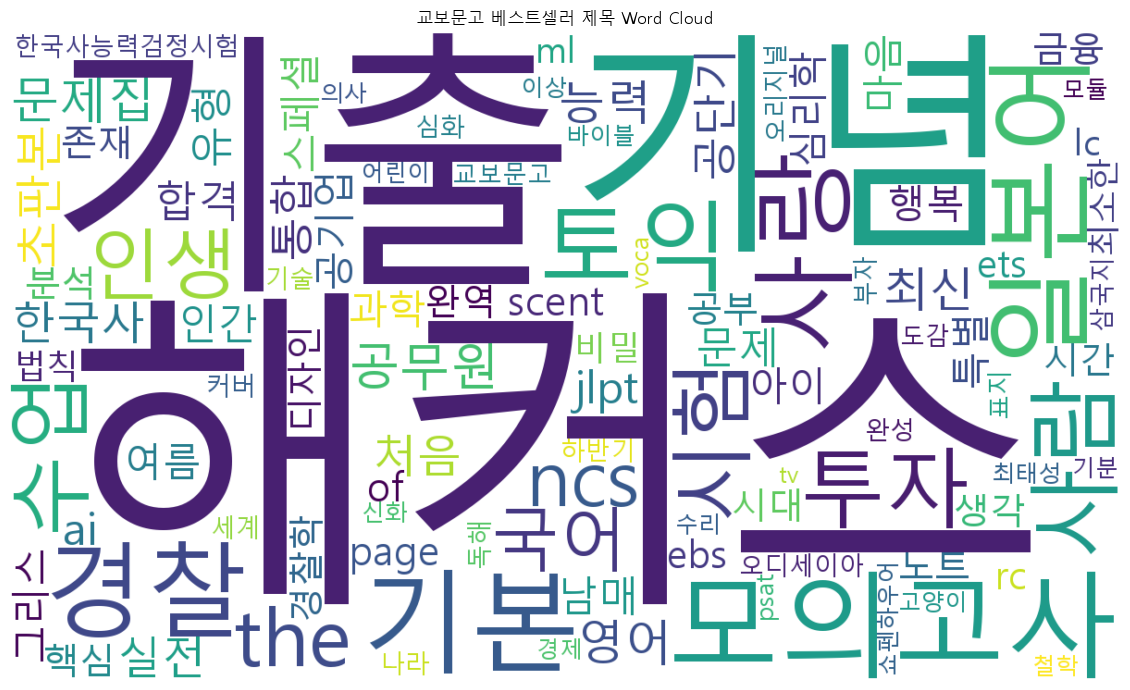

사용한 제목 수: 986
최종 단어 수: 2856
빈도 합: 2856
Top 10: [('해커스', 51), ('기출', 40), ('기념', 28), ('모의고사', 24), ('기본', 23), ('일본어', 22), ('경찰', 20), ('사랑', 20), ('토익', 19), ('사람', 17)]


In [51]:
from pathlib import Path
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
from kiwipiepy import Kiwi
from wordcloud import WordCloud

# 1. 데이터 불러오기
DATA_PATH = "book_bestseller_clean.csv"
df_books = pd.read_csv(DATA_PATH, encoding="utf-8-sig")

# 2. 제목 준비
titles = (
    df_books["상품명"]
    .fillna("")
    .astype(str)
    .str.strip()
)
titles = titles[titles != ""]

# 3. 형태소 분석기와 조건 준비
kiwi = Kiwi()
TARGET_TAGS = {"NNG", "NNP", "SL"}
MIN_LENGTH = 2
STOPWORDS = {
    "세트",
    "개정판",
    "에디션",
    "리커버",
    "한정판",
}

# 4. 단어 추출 함수
def extract_words(text):
    result = []
    for token in kiwi.tokenize(str(text)):
        if token.tag not in TARGET_TAGS:
            continue
        word = token.form.strip().lower()
        if len(word) < MIN_LENGTH:
            continue
        if word in STOPWORDS:
            continue
        result.append(word)
    return result

# 5. 전체 제목에서 단어 추출
final_words = []
for title in titles:
    final_words.extend(extract_words(title))

# 6. 빈도 계산
final_counter = Counter(final_words)

# 7. 상위 30개 표
top30 = pd.DataFrame(
    final_counter.most_common(30),
    columns=["단어", "빈도"]
)
display(top30)

# 8. 결과 저장
top30.to_csv(
    "chapter02_top30_words.csv",
    index=False,
    encoding="utf-8-sig",
)

# 9. Word Cloud
FONT_PATH = Path("C:/Windows/Fonts/malgun.ttf")
if not FONT_PATH.exists():
    raise FileNotFoundError(f"한글 폰트 파일을 찾을 수 없습니다: {FONT_PATH}")

wordcloud = WordCloud(
    font_path=str(FONT_PATH),
    width=1200,
    height=700,
    background_color="white",
    max_words=100,
    random_state=42,
).generate_from_frequencies(final_counter)

plt.figure(figsize=(12, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("교보문고 베스트셀러 제목 Word Cloud")
plt.tight_layout()
plt.show()

wordcloud.to_file("chapter02_wordcloud.png")

# 10. 간단한 검증
print("사용한 제목 수:", len(titles))
print("최종 단어 수:", len(final_words))
print("빈도 합:", sum(final_counter.values()))
print("Top 10:", final_counter.most_common(10))

---
# 실습 30. 오류가 발생했을 때 확인 순서

텍스트 분석은 여러 라이브러리와 데이터 조건을 사용하므로 오류가 날 수 있다.
오류가 나면 **무작정 전체 코드를 다시 작성하지 않는다.**

### 1단계. 오류가 발생한 셀 확인
어느 코드에서 **처음** 오류가 났는지 확인한다.

### 2단계. 오류 메시지 마지막 부분 확인

```
FileNotFoundError
KeyError: '상품명'
ModuleNotFoundError: No module named 'kiwipiepy'
ModuleNotFoundError: No module named 'wordcloud'
```

### 3단계. 데이터와 환경 확인 (아래 셀)

### 4단계. 인공지능에게 최소 수정 요청

```
다음 Python 코드를 실행했는데 오류가 발생했습니다.
[실제 코드 붙여넣기]
오류 메시지는 다음과 같습니다.
[실제 오류 메시지 붙여넣기]
현재 코드를 전부 새로 작성하지 말고,
오류 원인을 초보자가 이해할 수 있게 설명한 뒤
수정해야 할 부분만 최소한으로 알려주세요.
```

## 프롬프트 예시

```
Notebook에서 오류가 났을 때 확인할 기본 정보를 출력하고 싶습니다.
현재 작업 폴더, 데이터 파일 존재 여부, DataFrame의 컬럼 목록을 보여 주세요.
함수로 만들지 말고 바로 실행되는 코드로 작성해 주세요.
try/except 예외 처리는 넣지 마세요.
5줄 이내로 짧게 작성해 주세요.
설명은 코드 옆 짧은 주석으로만 달아 주세요.
```

In [52]:
# 3단계. 데이터와 환경 확인
print("현재 폴더:", Path.cwd())
print("데이터 파일 존재:", Path(DATA_PATH).exists())
print("컬럼 목록:", df_books.columns.tolist())

현재 폴더: C:\dev\llm-data-analysis-course\notebooks\book-text-ml
데이터 파일 존재: True
컬럼 목록: ['순위', '판매상품ID', '상품명', '판매가', '저자', '출판사', '발행일', '분야']


---
# 실습 31. 결과가 이상할 때 확인할 것

코드가 오류 없이 실행되어도 결과가 이상할 수 있다.

### 상위 단어가 전부 의미 없어 보일 때
- 품사 필터가 적용되었는가?
- 최소 글자수 조건이 적용되었는가?
- 불용어가 필요한가?

### 중요한 단어가 사라졌을 때
- `MIN_LENGTH`가 너무 큰가?
- 불용어에 잘못 포함되었는가?
- Kiwi가 예상과 다른 품사로 분석했는가?

한 제목을 직접 분석해 보면 원인을 찾을 수 있다. (아래 셀)

### 영문 단어가 따로 집계될 때
대소문자가 통일되었는지 확인한다. -> `token.form.strip().lower()`

### Word Cloud 한글이 깨질 때
한글 폰트 경로가 올바른지 확인한다. -> `FONT_PATH.exists()`

## 프롬프트 예시

```
Kiwi 객체 kiwi와 조건(TARGET_TAGS, MIN_LENGTH, STOPWORDS)이 있습니다.
제목 하나가 어떻게 형태소 분석되는지 직접 보고 싶습니다.
형태소마다 품사를 출력하고, 최종 단어로 살아남는지 여부도
O / X로 표시해 주세요.
try/except 예외 처리는 넣지 마세요.
초보자가 읽기 쉽게 10줄 이내로 짧게 작성해 주세요.
설명은 코드 옆 짧은 주석으로만 달아 주세요.
```

In [53]:
# 특정 제목이 어떻게 분석되는지 직접 확인
check_title = titles.iloc[0]
print("확인할 제목:", check_title)
print()
for token in kiwi.tokenize(check_title):
    keep = "O" if (token.tag in TARGET_TAGS
                   and len(token.form.strip()) >= MIN_LENGTH
                   and token.form.strip().lower() not in STOPWORDS) else "X"
    print(f"  {keep}  {token.form}  ({token.tag})")

확인할 제목: 세네카, 오늘을 빼앗기고 있는 당신에게

  O  세네카  (NNP)
  X  ,  (SP)
  O  오늘  (NNG)
  X  을  (JKO)
  X  빼앗기  (VV)
  X  고  (EC)
  X  있  (VX)
  X  는  (ETM)
  X  당신  (NP)
  X  에게  (JKB)


---
# 실습 32. 이번 Chapter의 분석 조건 기록하기

재현 가능한 분석을 위해 어떤 조건을 사용했는지 기록한다.
이 기록이 있으면 나중에 결과가 달라졌을 때 **어떤 조건이 바뀌었는지** 확인하기 쉽다.

## 분석 조건

- 데이터: Chapter 01에서 전처리한 `book_bestseller_clean.csv`
- 분석 컬럼: `상품명`
- 형태소 분석기: Kiwi (kiwipiepy)
- 사용 품사: `NNG`(일반 명사), `NNP`(고유 명사), `SL`(영문)
- 최소 단어 길이: 2글자
- 영문 처리: 소문자로 통일
- 불용어: 세트, 개정판, 에디션, 리커버, 한정판 (상위 빈도 결과를 확인한 뒤 지정)
- 빈도 집계: `collections.Counter`
- 시각화: 막대그래프 + Word Cloud

---
# 실습 33. Notebook 최종 실행 확인

제출 또는 다음 Chapter로 넘어가기 전에 Notebook을 처음부터 다시 실행한다.

> Kernel Restart -> Run All -> 마지막 셀까지 오류 없이 실행되는지 확인

## 확인 체크리스트

- [x] `book_bestseller_clean.csv`를 정상적으로 불러왔다.
- [x] 상품명 컬럼을 확인했다.
- [x] Dictionary로 빈도 누적 원리를 이해했다.
- [x] Counter로 빈도를 계산했다.
- [x] pandas `value_counts()` 결과도 확인했다.
- [x] 단순 토큰화의 한계를 확인했다.
- [x] Kiwi 형태소 분석 결과를 직접 확인했다.
- [x] 사용할 품사를 명시했다.
- [x] 최소 글자수 조건을 적용했다.
- [x] 불용어를 실제 결과를 보고 결정했다.
- [x] 상위 30개 단어를 표로 확인했다.
- [x] `chapter02_top30_words.csv`를 저장했다.
- [x] Word Cloud를 생성했다.
- [x] `chapter02_wordcloud.png`를 저장했다.
- [x] 상위 단어를 원본 제목에서 다시 확인했다.
- [x] Word Cloud를 과도하게 해석하지 않았다.
- [x] 실제 결과를 바탕으로 Markdown을 작성했다.

---
# 실습 34. 이번 Chapter에서 꼭 기억할 개념

### 1. 빈도 분석은 같은 값을 세는 작업에서 시작한다
> 단어 -> 등장할 때마다 1 증가 -> 단어별 등장 횟수 계산

Dictionary를 이용하면 이 원리를 직접 확인할 수 있다.

### 2. Counter와 value_counts()는 같은 목적을 더 편리하게 수행한다
| 도구 | 역할 |
|---|---|
| Dictionary | 원리 이해 |
| Counter | Python에서 간단한 빈도 집계 |
| `value_counts()` | pandas Series에서 간단한 빈도 집계 |

### 3. 한국어는 단순 공백 분리만으로 부족하다
형태소 분석을 이용하면 품사를 확인하고 명사 중심으로 단어를 추출할 수 있다.

### 4. 전처리 조건은 결과에 영향을 준다
사용 품사 / 최소 글자수 / 불용어 / 영문 대소문자 처리에 따라 상위 단어가 달라진다.

### 5. Word Cloud는 빈도를 시각적으로 표현한다
큰 단어는 **이번 조건에서 많이 등장한 단어**다.
판매 원인이나 독자의 선호를 직접 의미하지 않는다.

---
# 실습 35. Chapter 02 결과물 정리

이번 Chapter가 끝나면 다음 결과를 가지고 있어야 한다.

```
chapter02.ipynb
chapter02_top30_words.csv
chapter02_wordcloud.png
```

Notebook 안에는 다음 내용이 남아 있어야 한다.

데이터 불러오기 / Dictionary 빈도 집계 실습 / Counter 빈도 집계 /
pandas `value_counts()` 비교 / 단순 토큰화 / Kiwi 품사 확인 /
명사 중심 단어 추출 / 최소 글자수 필터링 / 불용어 제거 /
상위 30개 빈도표 / Word Cloud / 원본 데이터 검증 / 결과 해석 Markdown

---

## 다음 Chapter 연결

이번 Chapter에서는 도서 제목을 단어 단위로 나누고 빈도를 계산했다.
하지만 머신러닝 모델은 텍스트를 그대로 계산할 수 없다.

> 도서 제목 -> 단어 -> 단어 등장 횟수 -> **숫자 벡터**

Chapter 03에서는 `CountVectorizer`로 Bag of Words 방식의 단어-문서 행렬을 만들고,
`TF-IDF`로 단어의 상대적인 중요도를 숫자로 표현한다.